In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan Approval Final Project/Loan_data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
# Data preprocessing
df = df.dropna()

In [7]:
# Encode categorical variables
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Married'] = df['Married'].map({'Yes':1, 'No':0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

# Features and target
X = df[['Gender','Married','Education','ApplicantIncome','LoanAmount','Credit_History']]
y = df['Loan_Status']

In [8]:
# Features and target
X = df[['Gender','Married','Education','ApplicantIncome','LoanAmount','Credit_History']]
y = df['Loan_Status']

In [9]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [16]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [21]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
# Artificial Neural Network (ANN)
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(max_iter=500)
ann.fit(X_train, y_train)

MLPClassifier(max_iter=500)

In [14]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = [lr, dt, rf]
names = ["Logistic Regression", "Decision Tree", "Random Forest"]

for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("------")

Logistic Regression
Accuracy: 0.7986111111111112
              precision    recall  f1-score   support

           0       0.94      0.36      0.52        44
           1       0.78      0.99      0.87       100

    accuracy                           0.80       144
   macro avg       0.86      0.68      0.70       144
weighted avg       0.83      0.80      0.77       144

[[16 28]
 [ 1 99]]
------
Decision Tree
Accuracy: 0.7291666666666666
              precision    recall  f1-score   support

           0       0.56      0.52      0.54        44
           1       0.80      0.82      0.81       100

    accuracy                           0.73       144
   macro avg       0.68      0.67      0.67       144
weighted avg       0.72      0.73      0.73       144

[[23 21]
 [18 82]]
------
Random Forest
Accuracy: 0.7986111111111112
              precision    recall  f1-score   support

           0       0.83      0.43      0.57        44
           1       0.79      0.96      0.87       

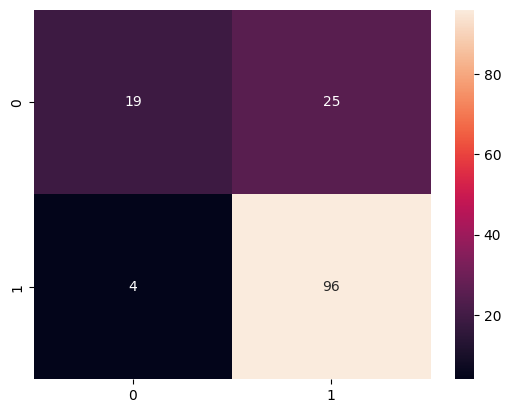

In [15]:
# Confusion Matrix plot
sns.heatmap(confusion_matrix(y_test, rf.predict(X_test)), annot=True)
plt.show()